In [6]:
import os
import sys

# 1. Point to the folder containing 'src'
# This goes up one level from /notebooks to the Project Root
project_root = os.path.abspath(os.path.join('..'))

if project_root not in sys.path:
    sys.path.append(project_root)

# 2. Use an ABSOLUTE import (No dots at the start!)
# If your file is named regularization.py, use:
from src.pipeline1 import train_model, evaluate_model, compute_pr_auc, plot_pr_curve, load_data, split_data

# If your file is named pipeline1.py, use:
# from src.pipeline1 import train_model, evaluate_model, compute_pr_auc, plot_pr_curve

print("Functions imported successfully!")

Functions imported successfully!


In [7]:
# Load and Split
X, y = load_data()
X_train, X_test, y_train, y_test = split_data(X, y)
    
print(f"Data loaded successfully.")
print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")    
print(f"Test shapes:  X={X_test.shape}, y={y_test.shape}")

Data loaded successfully.
Train shapes: X=(12480, 10), y=(12480,)
Test shapes:  X=(3120, 10), y=(3120,)


### TRAIN LOGISTIC REGRESSION

In [8]:
model = train_model(X_train, y_train)

### MAKE PREDICTIONS & EVALUATE MODEL:

In [ ]:
evaluate_model(model, X_test, y_test)

Accuracy: 0.7891025641025641
F1 Score: 0.1273209549071618
              precision    recall  f1-score   support

           0       0.79      0.99      0.88      2432
           1       0.73      0.07      0.13       688

    accuracy                           0.79      3120
   macro avg       0.76      0.53      0.50      3120
weighted avg       0.78      0.79      0.71      3120



### PR-AUC

In [14]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc

y_scores = model.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

PR-AUC: 0.4282507404422604


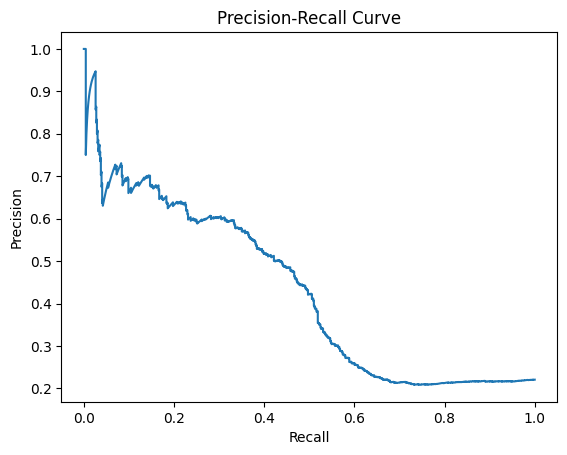

In [15]:
import matplotlib.pyplot as plt
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()